# EM with Soft-Label KDE Refitting
# 一坨大便

 Uses unannotated spectra to expand the training set. The model scores every hit, assigns soft TP/FP labels based on the
  posterior, and refits the KDEs on those soft labels.                                                                           
   
  The assumption: the current model's posteriors are approximately correct — high posterior hits are probably TP, low posterior  
  hits are probably FP. They aren't. The initial model is already biased: it assigns high posteriors to high-similarity hits
  because the in-house FP never reaches 0.5. So the E-step labels all high-similarity unannotated hits as TP, and all            
  low-similarity ones as FP. The M-step refits the KDEs on those labels — which just recreates the same truncated FP
  distribution, but now with more data reinforcing it.

  Why it failed: the soft labels from a biased model are themselves biased. EM amplifies whatever the starting model believes.   



**Problem:** The in-house TP/FP KDEs are built from 1,631 biased annotated spectra.  
The FP distribution is truncated (nothing above ~0.5) because wrong candidates only
appear alongside easily-confirmed spectra.

**Idea:** Use all 180k+ hits (annotated + unannotated) to refit the KDEs.  
For unannotated hits we don't have hard labels — but the model gives us soft posteriors.

**EM algorithm:**
- **E-step:** score all hits with the current model → P(correct | hit) for each hit
- **M-step:** refit weighted KDEs using those soft posteriors
  - TP weight of hit i = post_i
  - FP weight of hit i = 1 − post_i
- Annotated hits use **hard** InChIKey14 labels (ground truth anchors the model)
- Unannotated hits use **soft** posteriors
- Iterate until KDEs converge

**Mixing parameter α:** at each iteration, new KDE = α × EM estimate + (1−α) × previous.  
Prevents rapid drift toward wrong fixed point if initial posteriors are biased.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm as sp_norm, gaussian_kde
from scipy.special import kl_div

warnings.filterwarnings('ignore')
np.random.seed(42)

ROOT     = '/Users/ellayoung/Desktop/metabolo_confi_score'
DATA_DIR = f'{ROOT}/data'
OUT_DIR  = f'{ROOT}/out_proposal'

# ── pipeline constants (same as proposal_mvp) ─────────────────────────────
SIGMA_BROAD    = 50.0
SIGMA_RT_BROAD = 300.0
P_MS1_NULL     = sp_norm.pdf(0.0, 0.0, SIGMA_BROAD)
P_RT_NULL      = sp_norm.pdf(0.0, 0.0, SIGMA_RT_BROAD)
NOTA_THRESH    = 0.6
sigma_M        = 4.21
sigma_RT_anno  = 14.1
sigma_RT_ref   = 19.1
p_novel_est    = 0.224
BW             = 0.05
sim_grid       = np.linspace(0.0, 1.0, 2000)

## Part 1 — Load All Data

In [2]:
print('Loading spectra and hits...')
spectra_raw = pd.read_csv(f'{DATA_DIR}/ttof+neg+hilic.csv')
hits_a      = pd.read_csv(f'{DATA_DIR}/hilic_ttof_neg_masswiki_hits_new.csv')
hits_u      = pd.read_csv(f'{DATA_DIR}/hilic_ttof_neg_masswiki_hits_unconfirmed.csv')
hits_raw    = pd.concat([hits_a, hits_u], ignore_index=True)

specs = spectra_raw[['wiki_id','rt','precursor_mz','entropy','is_manual_annotated']].copy()
specs['wiki_id']   = specs['wiki_id'].astype(str)
specs['confirmed'] = specs['is_manual_annotated'].fillna(False).astype(bool)
hits_raw['wiki_id'] = hits_raw['wiki_id'].astype(str)

joint = hits_raw.merge(
    specs[['wiki_id','rt','precursor_mz','entropy','confirmed']],
    on='wiki_id', how='inner'
)
joint['delta_ppm'] = ((joint['precursor_mz'] - joint['lib_precursor_mz'])
                       / joint['lib_precursor_mz'] * 1e6)
joint['delta_rt']  = joint.apply(
    lambda r: r['anno_delta_rt']
              if r['hit_source'] == 'annotation' and pd.notna(r.get('anno_delta_rt'))
              else (r['rt'] - r['predicted_rt_hilic']
                    if r['hit_source'] == 'reference' and pd.notna(r.get('predicted_rt_hilic'))
                    else np.nan),
    axis=1
)

# Hard labels for annotated hits (ground truth anchor)
assertions = pd.read_csv(f'{OUT_DIR}/assertions.csv')
correct_map = assertions.groupby(['wiki_id','lib_name'])['correct'].first().to_dict()
joint['correct'] = joint.apply(
    lambda r: correct_map.get((str(r['wiki_id']), r['lib_name']), False), axis=1
)

anno_wids  = set(specs[specs['confirmed']]['wiki_id'])
anno_joint = joint[joint['wiki_id'].isin(anno_wids)].copy()
unno_joint = joint[~joint['wiki_id'].isin(anno_wids)].copy()

print(f'Total hits:       {len(joint):,}')
print(f'Annotated hits:   {len(anno_joint):,}  ({anno_joint["wiki_id"].nunique():,} spectra)')
print(f'Unannotated hits: {len(unno_joint):,}  ({unno_joint["wiki_id"].nunique():,} spectra)')
print(f'Hard TP labels:   {anno_joint["correct"].sum():,}')
print(f'Hard FP labels:   {(~anno_joint["correct"]).sum():,}')

Loading spectra and hits...
Total hits:       287,905
Annotated hits:   137,490  (1,883 spectra)
Unannotated hits: 150,415  (3,964 spectra)
Hard TP labels:   51,429
Hard FP labels:   86,061


## Part 2 — Initialise KDEs (Iteration 0)

Start from the in-house annotated KDEs — same as the current pipeline baseline.

In [3]:
def fit_kdes(tp_scores, fp_scores, bw=BW):
    kde_tp = gaussian_kde(tp_scores, bw_method=bw)
    kde_fp = gaussian_kde(fp_scores, bw_method=bw)
    return kde_tp, kde_fp


def make_lr_grid(kde_tp, kde_fp):
    return np.clip(kde_tp(sim_grid) / (kde_fp(sim_grid) + 1e-10), 0.0, 1000.0)


def null_adj_lr_fn(lr_grid_):
    """Return a closure over lr_grid for use in scoring."""
    def fn(sims, H, alpha_=10.0):
        lam    = 1.0 - np.exp(-alpha_ * H)
        abs_lr = np.interp(sims, sim_grid, lr_grid_)
        return lam * abs_lr + (1.0 - lam)
    return fn


# Iteration 0: hard-label annotated KDEs
tp_init = anno_joint[anno_joint['correct']]['entropy_similarity'].dropna().values
fp_init = anno_joint[~anno_joint['correct']]['entropy_similarity'].dropna().values

kde_tp_0, kde_fp_0 = fit_kdes(tp_init, fp_init)
lr_grid_0 = make_lr_grid(kde_tp_0, kde_fp_0)

print(f'Init TP: n={len(tp_init):,}  mean={tp_init.mean():.3f}')
print(f'Init FP: n={len(fp_init):,}  mean={fp_init.mean():.3f}')

Init TP: n=51,429  mean=0.659
Init FP: n=86,061  mean=0.363


## Part 3 — E-step and M-step Functions

In [4]:
def e_step(df, lr_fn, alpha_=10.0):
    """
    Score all hits and return soft posterior P(correct | hit) for each row.
    Returns a Series of posteriors aligned with df.index.
    """
    post_vals = np.zeros(len(df))
    idx_map   = {wid: grp for wid, grp in df.groupby('wiki_id')}

    for wid, g in idx_map.items():
        H      = float(g['entropy'].iloc[0])
        N      = len(g)
        LR_ms2 = lr_fn(g['entropy_similarity'].fillna(0).values, H, alpha_)
        p_ms1  = sp_norm.pdf(g['delta_ppm'].values, 0.0, sigma_M)
        LR_ms1 = p_ms1 / P_MS1_NULL
        LR_rt  = np.ones(N)
        has_rt = g['delta_rt'].notna().values
        dr     = g['delta_rt'].fillna(0.0).values
        m_a    = (g['hit_source'] == 'annotation').values & has_rt
        m_r    = (g['hit_source'] == 'reference').values  & has_rt
        if m_a.any(): LR_rt[m_a] = sp_norm.pdf(dr[m_a], 0.0, sigma_RT_anno) / P_RT_NULL
        if m_r.any(): LR_rt[m_r] = sp_norm.pdf(dr[m_r], 0.0, sigma_RT_ref)  / P_RT_NULL
        priors = np.full(N, (1.0 - p_novel_est) / N)
        unnorm = priors * LR_ms2 * LR_ms1 * LR_rt
        total  = unnorm.sum() + p_novel_est
        post   = unnorm / total if total > 1e-300 else np.full(N, 1.0 / N)
        post_vals[g.index - df.index[0]] = post

    return pd.Series(post_vals, index=df.index)


def m_step(anno_df, unno_df, unno_post,
           kde_tp_prev, kde_fp_prev, mix_alpha=0.3, bw=BW):
    """
    Refit KDEs using:
      - Hard labels for annotated hits (weight=1 for correct, 0 for incorrect)
      - Soft posteriors for unannotated hits
    Then mix: new = mix_alpha * EM_estimate + (1 - mix_alpha) * previous
    """
    sim_all = joint['entropy_similarity'].dropna()

    # annotated: hard weights
    anno_sim = anno_df['entropy_similarity'].fillna(0).values
    anno_w_tp = anno_df['correct'].astype(float).values
    anno_w_fp = 1.0 - anno_w_tp

    # unannotated: soft weights from E-step
    unno_sim  = unno_df['entropy_similarity'].fillna(0).values
    unno_w_tp = unno_post.values
    unno_w_fp = 1.0 - unno_w_tp

    # combine — down-weight unannotated to prevent them from overwhelming annotated
    n_anno  = len(anno_df)
    n_unno  = len(unno_df)
    scale   = n_anno / n_unno  # equal effective sample size per spectrum

    all_sim  = np.concatenate([anno_sim,  unno_sim])
    all_w_tp = np.concatenate([anno_w_tp, unno_w_tp * scale])
    all_w_fp = np.concatenate([anno_w_fp, unno_w_fp * scale])

    # avoid zero-weight KDEs
    all_w_tp = np.clip(all_w_tp, 1e-6, None)
    all_w_fp = np.clip(all_w_fp, 1e-6, None)

    # fit EM KDEs on combined weighted data
    kde_tp_em = gaussian_kde(all_sim, bw_method=bw, weights=all_w_tp / all_w_tp.sum())
    kde_fp_em = gaussian_kde(all_sim, bw_method=bw, weights=all_w_fp / all_w_fp.sum())

    # mix with previous iteration
    tp_mixed = mix_alpha * kde_tp_em(sim_grid) + (1 - mix_alpha) * kde_tp_prev(sim_grid)
    fp_mixed = mix_alpha * kde_fp_em(sim_grid) + (1 - mix_alpha) * kde_fp_prev(sim_grid)

    # return as callable by wrapping in interpolation
    from scipy.interpolate import interp1d
    kde_tp_new = interp1d(sim_grid, np.clip(tp_mixed, 1e-10, None),
                          bounds_error=False, fill_value='extrapolate')
    kde_fp_new = interp1d(sim_grid, np.clip(fp_mixed, 1e-10, None),
                          bounds_error=False, fill_value='extrapolate')

    return kde_tp_new, kde_fp_new, kde_tp_em, kde_fp_em


def calibration_table(df, lr_fn, alpha_=10.0):
    """Calibration accuracy on the annotated set."""
    BIN_EDGES = [(0.90, 1.01, '>0.90'), (0.70, 0.90, '0.70-0.90'),
                 (0.50, 0.70, '0.50-0.70'), (0.30, 0.50, '0.30-0.50'), (0.0, 0.30, '<0.30')]
    top_rows = []
    for wid, g in df.groupby('wiki_id'):
        H      = float(g['entropy'].iloc[0])
        N      = len(g)
        LR_ms2 = lr_fn(g['entropy_similarity'].fillna(0).values, H, alpha_)
        p_ms1  = sp_norm.pdf(g['delta_ppm'].values, 0.0, sigma_M)
        LR_ms1 = p_ms1 / P_MS1_NULL
        LR_rt  = np.ones(N)
        has_rt = g['delta_rt'].notna().values
        dr     = g['delta_rt'].fillna(0.0).values
        m_a    = (g['hit_source'] == 'annotation').values & has_rt
        m_r    = (g['hit_source'] == 'reference').values  & has_rt
        if m_a.any(): LR_rt[m_a] = sp_norm.pdf(dr[m_a], 0.0, sigma_RT_anno) / P_RT_NULL
        if m_r.any(): LR_rt[m_r] = sp_norm.pdf(dr[m_r], 0.0, sigma_RT_ref)  / P_RT_NULL
        priors = np.full(N, (1.0 - p_novel_est) / N)
        unnorm = priors * LR_ms2 * LR_ms1 * LR_rt
        total  = unnorm.sum() + p_novel_est
        post   = unnorm / total if total > 1e-300 else np.full(N, 1.0/N)
        best   = post.argmax()
        p_nov  = float(p_novel_est / total) if total > 1e-300 else p_novel_est
        top_rows.append({'post_top': float(post[best]),
                         'correct' : bool(g['correct'].iloc[best]),
                         'P_novel' : p_nov})
    df_top = pd.DataFrame(top_rows)
    called = df_top[df_top['P_novel'] < NOTA_THRESH]
    out = []
    for lo, hi, lbl in BIN_EDGES:
        sub = called[(called['post_top'] >= lo) & (called['post_top'] < hi)]
        out.append({'bin': lbl, 'n': len(sub),
                    'acc': round(sub['correct'].mean(), 4) if len(sub) > 0 else np.nan})
    return pd.DataFrame(out)


def kl_divergence_grids(g1, g2):
    """Symmetric KL divergence between two density grids."""
    p = np.clip(g1, 1e-10, None); p /= p.sum()
    q = np.clip(g2, 1e-10, None); q /= q.sum()
    return float(np.sum(kl_div(p, q)) + np.sum(kl_div(q, p)))


print('Functions defined.')

Functions defined.


## Part 4 — EM Loop

Run for `N_ITER` iterations. At each iteration:
1. E-step: score **all unannotated** hits with current LR function → soft posteriors
2. M-step: refit KDEs using hard (annotated) + soft (unannotated) labels, mix with previous
3. Log: KL divergence of TP/FP KDE grids, calibration on annotated set

In [5]:
N_ITER    = 6
MIX_ALPHA = 0.3   # conservative: move 30% toward EM estimate per iteration

# ── history tracking ──────────────────────────────────────────────────────
history = {
    'iter'        : [],
    'kl_tp'       : [],
    'kl_fp'       : [],
    'tp_mean'     : [],
    'fp_mean'     : [],
    'lr_grid'     : [],
    'tp_grid'     : [],
    'fp_grid'     : [],
    'calibration' : [],
}

# Iteration 0 baseline
lr_fn_cur  = null_adj_lr_fn(lr_grid_0)
cal_0      = calibration_table(anno_joint, lr_fn_cur)
history['iter'].append(0)
history['kl_tp'].append(0.0)
history['kl_fp'].append(0.0)
history['tp_grid'].append(kde_tp_0(sim_grid).copy())
history['fp_grid'].append(kde_fp_0(sim_grid).copy())
history['lr_grid'].append(lr_grid_0.copy())
history['tp_mean'].append(float(np.average(sim_grid, weights=kde_tp_0(sim_grid))))
history['fp_mean'].append(float(np.average(sim_grid, weights=kde_fp_0(sim_grid))))
history['calibration'].append(cal_0)

kde_tp_cur = kde_tp_0
kde_fp_cur = kde_fp_0
lr_grid_cur = lr_grid_0

# Reset index for safe positional indexing in e_step
unno_joint_r = unno_joint.reset_index(drop=True)

print(f'Starting EM — {N_ITER} iterations, mix_alpha={MIX_ALPHA}')
print(f'{"Iter":>5} {"KL_TP":>9} {"KL_FP":>9} {"TP_mean":>9} {"FP_mean":>9}')
print('-' * 50)

for it in range(1, N_ITER + 1):

    # ── E-step ─────────────────────────────────────────────────────────────
    lr_fn_cur = null_adj_lr_fn(lr_grid_cur)
    unno_post = e_step(unno_joint_r, lr_fn_cur)

    # ── M-step ─────────────────────────────────────────────────────────────
    kde_tp_new, kde_fp_new, kde_tp_em, kde_fp_em = m_step(
        anno_joint, unno_joint_r, unno_post,
        kde_tp_cur, kde_fp_cur, mix_alpha=MIX_ALPHA
    )

    tp_grid_new = np.clip(kde_tp_new(sim_grid), 1e-10, None)
    fp_grid_new = np.clip(kde_fp_new(sim_grid), 1e-10, None)
    lr_grid_new = np.clip(tp_grid_new / (fp_grid_new + 1e-10), 0.0, 1000.0)

    # ── convergence metrics ────────────────────────────────────────────────
    kl_tp = kl_divergence_grids(tp_grid_new, lr_grid_cur * 0 + kde_tp_cur(sim_grid))
    kl_fp = kl_divergence_grids(fp_grid_new, kde_fp_cur(sim_grid))
    tp_mean = float(np.average(sim_grid, weights=tp_grid_new / tp_grid_new.sum()))
    fp_mean = float(np.average(sim_grid, weights=fp_grid_new / fp_grid_new.sum()))

    # ── calibration on annotated set ───────────────────────────────────────
    lr_fn_new = null_adj_lr_fn(lr_grid_new)
    cal_it    = calibration_table(anno_joint, lr_fn_new)

    print(f'{it:>5} {kl_tp:>9.4f} {kl_fp:>9.4f} {tp_mean:>9.4f} {fp_mean:>9.4f}')

    # ── store ──────────────────────────────────────────────────────────────
    history['iter'].append(it)
    history['kl_tp'].append(kl_tp)
    history['kl_fp'].append(kl_fp)
    history['tp_mean'].append(tp_mean)
    history['fp_mean'].append(fp_mean)
    history['tp_grid'].append(tp_grid_new.copy())
    history['fp_grid'].append(fp_grid_new.copy())
    history['lr_grid'].append(lr_grid_new.copy())
    history['calibration'].append(cal_it)

    kde_tp_cur  = kde_tp_new
    kde_fp_cur  = kde_fp_new
    lr_grid_cur = lr_grid_new

print('\nDone.')

Starting EM — 6 iterations, mix_alpha=0.3
 Iter     KL_TP     KL_FP   TP_mean   FP_mean
--------------------------------------------------
    1    0.0013    0.0231    0.6490    0.3302
    2    0.0006    0.0108    0.6464    0.3063
    3    0.0003    0.0053    0.6444    0.2895
    4    0.0001    0.0026    0.6431    0.2778
    5    0.0001    0.0013    0.6421    0.2695
    6    0.0000    0.0007    0.6414    0.2638

Done.


## Part 5 — Convergence Diagnostics

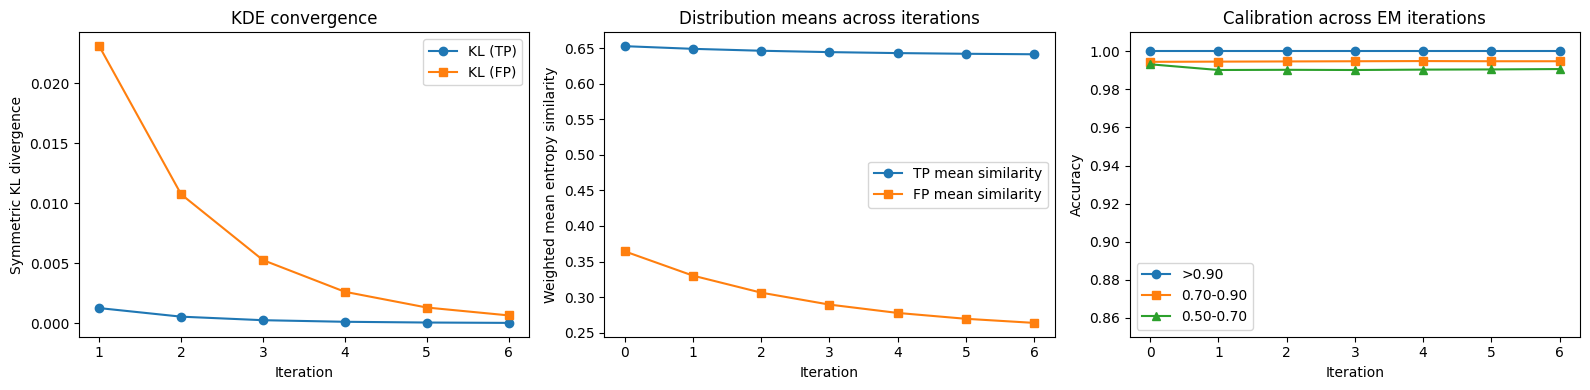

In [6]:
iters = history['iter']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# KL divergence
ax = axes[0]
ax.plot(iters[1:], history['kl_tp'][1:], marker='o', label='KL (TP)')
ax.plot(iters[1:], history['kl_fp'][1:], marker='s', label='KL (FP)')
ax.set_xlabel('Iteration')
ax.set_ylabel('Symmetric KL divergence')
ax.set_title('KDE convergence')
ax.legend()

# Weighted mean of TP and FP distributions
ax = axes[1]
ax.plot(iters, history['tp_mean'], marker='o', label='TP mean similarity')
ax.plot(iters, history['fp_mean'], marker='s', label='FP mean similarity')
ax.set_xlabel('Iteration')
ax.set_ylabel('Weighted mean entropy similarity')
ax.set_title('Distribution means across iterations')
ax.legend()

# Accuracy at >0.90 across iterations
ax = axes[2]
acc_90 = [cal[cal['bin']=='>0.90']['acc'].values[0] if '>0.90' in cal['bin'].values else np.nan
          for cal in history['calibration']]
acc_70 = [cal[cal['bin']=='0.70-0.90']['acc'].values[0] if '0.70-0.90' in cal['bin'].values else np.nan
          for cal in history['calibration']]
acc_50 = [cal[cal['bin']=='0.50-0.70']['acc'].values[0] if '0.50-0.70' in cal['bin'].values else np.nan
          for cal in history['calibration']]
ax.plot(iters, acc_90, marker='o', label='>0.90')
ax.plot(iters, acc_70, marker='s', label='0.70-0.90')
ax.plot(iters, acc_50, marker='^', label='0.50-0.70')
ax.set_xlabel('Iteration')
ax.set_ylabel('Accuracy')
ax.set_title('Calibration across EM iterations')
ax.legend()
ax.set_ylim(0.85, 1.01)

plt.tight_layout()
plt.savefig(f'{ROOT}/viz/em_convergence.png', dpi=150)
plt.show()

## Part 6 — KDE and LR Evolution

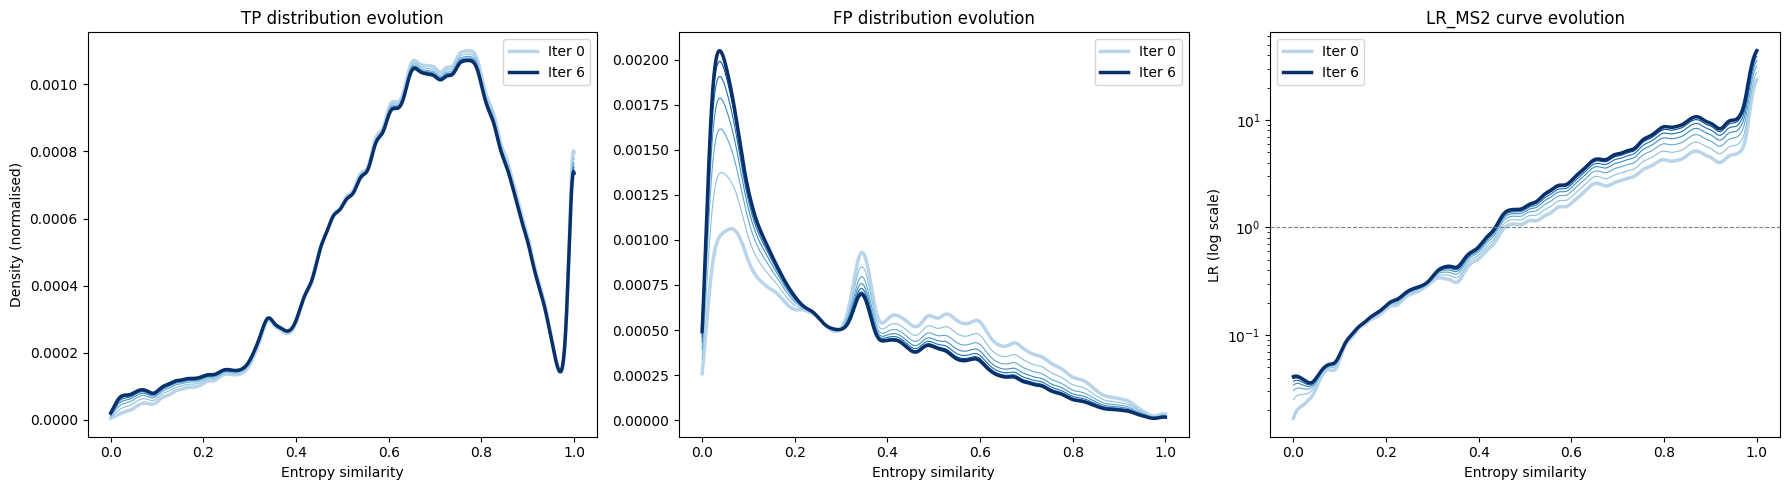

In [7]:
cmap   = plt.cm.Blues
n_show = len(iters)
colors = [cmap(0.3 + 0.7 * i / max(n_show - 1, 1)) for i in range(n_show)]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# TP evolution
ax = axes[0]
for i, (it, tp_g) in enumerate(zip(iters, history['tp_grid'])):
    lw = 2.5 if it in (0, iters[-1]) else 0.8
    label = f'Iter {it}' if it in (0, iters[-1]) else None
    ax.plot(sim_grid, tp_g / tp_g.sum(), color=colors[i], linewidth=lw, label=label)
ax.set_title('TP distribution evolution')
ax.set_xlabel('Entropy similarity')
ax.set_ylabel('Density (normalised)')
ax.legend()

# FP evolution
ax = axes[1]
for i, (it, fp_g) in enumerate(zip(iters, history['fp_grid'])):
    lw = 2.5 if it in (0, iters[-1]) else 0.8
    label = f'Iter {it}' if it in (0, iters[-1]) else None
    ax.plot(sim_grid, fp_g / fp_g.sum(), color=colors[i], linewidth=lw, label=label)
ax.set_title('FP distribution evolution')
ax.set_xlabel('Entropy similarity')
ax.legend()

# LR curve evolution
ax = axes[2]
for i, (it, lr_g) in enumerate(zip(iters, history['lr_grid'])):
    lw = 2.5 if it in (0, iters[-1]) else 0.8
    label = f'Iter {it}' if it in (0, iters[-1]) else None
    ax.plot(sim_grid, lr_g, color=colors[i], linewidth=lw, label=label)
ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.8)
ax.set_yscale('log')
ax.set_title('LR_MS2 curve evolution')
ax.set_xlabel('Entropy similarity')
ax.set_ylabel('LR (log scale)')
ax.legend()

plt.tight_layout()
plt.savefig(f'{ROOT}/viz/em_kde_evolution.png', dpi=150)
plt.show()

## Part 7 — Final Calibration Comparison

In [8]:
cal_final = history['calibration'][-1]
cal_base  = history['calibration'][0]

cal_base['model']  = 'Baseline (iter 0)'
cal_final['model'] = f'EM (iter {N_ITER})'
comp = pd.concat([cal_base, cal_final])

print('Calibration comparison:')
print(comp.pivot(index='bin', columns='model', values='acc').round(4).to_string())
print()
print('N called per bin:')
print(comp.pivot(index='bin', columns='model', values='n').to_string())

Calibration comparison:
model      Baseline (iter 0)  EM (iter 6)
bin                                      
0.30-0.50             0.9854       0.9796
0.50-0.70             0.9932       0.9907
0.70-0.90             0.9945       0.9948
<0.30                 0.8892       0.8987
>0.90                 1.0000       1.0000

N called per bin:
model      Baseline (iter 0)  EM (iter 6)
bin                                      
0.30-0.50                479          490
0.50-0.70                296          322
0.70-0.90                183          193
<0.30                    812          760
>0.90                     88           95


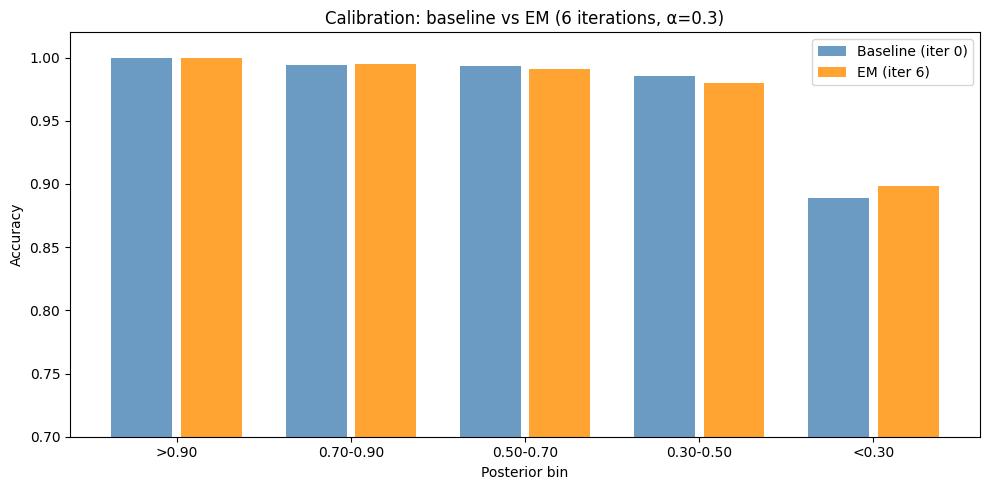

In [9]:
bin_order = ['>0.90','0.70-0.90','0.50-0.70','0.30-0.50','<0.30']
cal_b = cal_base.set_index('bin').reindex(bin_order)['acc']
cal_f = cal_final.set_index('bin').reindex(bin_order)['acc']

x   = np.arange(len(bin_order))
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - 0.2, cal_b, width=0.35, label='Baseline (iter 0)', alpha=0.8, color='steelblue')
ax.bar(x + 0.2, cal_f, width=0.35, label=f'EM (iter {N_ITER})',  alpha=0.8, color='darkorange')
ax.set_xticks(x)
ax.set_xticklabels(bin_order)
ax.set_ylim(0.7, 1.02)
ax.set_ylabel('Accuracy')
ax.set_xlabel('Posterior bin')
ax.set_title(f'Calibration: baseline vs EM ({N_ITER} iterations, α={MIX_ALPHA})')
ax.legend()
plt.tight_layout()
plt.savefig(f'{ROOT}/viz/em_calibration_comparison.png', dpi=150)
plt.show()

## Part 8 — What Changed in the FP Distribution?

The FP distribution is the key diagnostic — did EM recover the truncated tail?

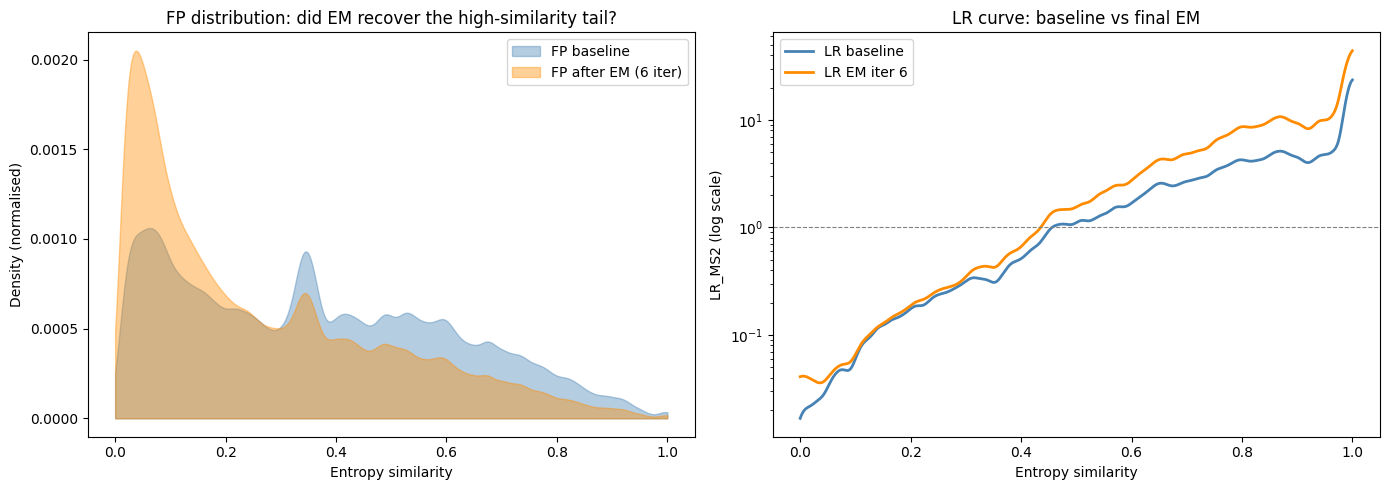

FP density above similarity=0.5:
  Baseline: 0.3102 (31.02%)
  EM final: 0.1773 (17.73%)

LR at similarity=1.0:
  Baseline: 23.6
  EM final: 44.1


In [10]:
fp_init_grid  = history['fp_grid'][0]
fp_final_grid = history['fp_grid'][-1]
tp_init_grid  = history['tp_grid'][0]
tp_final_grid = history['tp_grid'][-1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.fill_between(sim_grid, fp_init_grid  / fp_init_grid.sum(),
                alpha=0.4, color='steelblue', label='FP baseline')
ax.fill_between(sim_grid, fp_final_grid / fp_final_grid.sum(),
                alpha=0.4, color='darkorange', label=f'FP after EM ({N_ITER} iter)')
ax.set_title('FP distribution: did EM recover the high-similarity tail?')
ax.set_xlabel('Entropy similarity')
ax.set_ylabel('Density (normalised)')
ax.legend()

ax = axes[1]
ax.plot(sim_grid, history['lr_grid'][0],  color='steelblue',  label='LR baseline', linewidth=2)
ax.plot(sim_grid, history['lr_grid'][-1], color='darkorange', label=f'LR EM iter {N_ITER}', linewidth=2)
ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.8)
ax.set_yscale('log')
ax.set_xlabel('Entropy similarity')
ax.set_ylabel('LR_MS2 (log scale)')
ax.set_title('LR curve: baseline vs final EM')
ax.legend()

plt.tight_layout()
plt.savefig(f'{ROOT}/viz/em_fp_recovery.png', dpi=150)
plt.show()

# Quantify high-similarity FP mass
thresh = 0.5
fp_mass_init  = fp_init_grid[sim_grid  > thresh].sum() / fp_init_grid.sum()
fp_mass_final = fp_final_grid[sim_grid > thresh].sum() / fp_final_grid.sum()
print(f'FP density above similarity={thresh}:')
print(f'  Baseline: {fp_mass_init:.4f} ({fp_mass_init*100:.2f}%)')
print(f'  EM final: {fp_mass_final:.4f} ({fp_mass_final*100:.2f}%)')
print()
lr_at_10 = np.interp(1.0, sim_grid, history['lr_grid'][0])
lr_at_1_em = np.interp(1.0, sim_grid, history['lr_grid'][-1])
print(f'LR at similarity=1.0:')
print(f'  Baseline: {lr_at_10:.1f}')
print(f'  EM final: {lr_at_1_em:.1f}')

## Part 9 — Sensitivity to mix_alpha

How much does the choice of mixing weight matter?

In [11]:
# Quick single-iteration sweep over mix_alpha using the final unannotated posteriors
# (reuse the posteriors from the last E-step — no need to re-run the full loop)
lr_fn_final = null_adj_lr_fn(history['lr_grid'][-1])
unno_post_final = e_step(unno_joint_r, lr_fn_final)

alpha_sweep = [0.1, 0.2, 0.3, 0.5, 0.7, 1.0]
print(f'{"alpha":>7} | {"acc >0.90":>9} {"acc 0.70-0.90":>14} {"acc 0.50-0.70":>14} {"FP tail >0.5":>14}')
print('-' * 65)

for alpha_m in alpha_sweep:
    ktp, kfp, _, _ = m_step(anno_joint, unno_joint_r, unno_post_final,
                              kde_tp_cur, kde_fp_cur, mix_alpha=alpha_m)
    fp_g = np.clip(kfp(sim_grid), 1e-10, None)
    tp_g = np.clip(ktp(sim_grid), 1e-10, None)
    lr_g = np.clip(tp_g / (fp_g + 1e-10), 0.0, 1000.0)
    cal  = calibration_table(anno_joint, null_adj_lr_fn(lr_g))
    cal_d = cal.set_index('bin')
    a90  = cal_d.loc['>0.90',    'acc'] if '>0.90'    in cal_d.index else np.nan
    a70  = cal_d.loc['0.70-0.90','acc'] if '0.70-0.90' in cal_d.index else np.nan
    a50  = cal_d.loc['0.50-0.70','acc'] if '0.50-0.70' in cal_d.index else np.nan
    fp_tail = fp_g[sim_grid > 0.5].sum() / fp_g.sum()
    print(f'{alpha_m:>7.1f} | {a90:>9.4f} {a70:>14.4f} {a50:>14.4f} {fp_tail:>14.4f}')

  alpha | acc >0.90  acc 0.70-0.90  acc 0.50-0.70   FP tail >0.5
-----------------------------------------------------------------
    0.1 |    1.0000         0.9948         0.9908         0.1755
    0.2 |    1.0000         0.9948         0.9907         0.1737
    0.3 |    1.0000         0.9948         0.9907         0.1719
    0.5 |    1.0000         0.9949         0.9908         0.1684
    0.7 |    1.0000         0.9949         0.9907         0.1648
    1.0 |    1.0000         0.9949         0.9908         0.1595
